## Task 00

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import folium
import json
print("Let's go already!")
RESULTS = {}
plt.close("all")
RESULTS["task00"] = "ok"
print(json.dumps(RESULTS, sort_keys=True))

Let's go already!
{"task00": "ok"}


## Task01

In [5]:
import pandas as pd
from task00 import RESULTS


stock =pd.read_csv('stock.csv')
michelin=pd.read_csv('michelin.csv')
penguins=pd.read_csv('penguins.csv')

print("First 4 rows of stock:")
print(stock.head(4))
print("\nLast 2 rows of michelin:")
print(michelin.tail(2))
RESULTS["task01"]={
"stock_head_shape":list(stock.head(4).shape),
"michelin_tail_shape":list(michelin.tail(2).shape),
}


First 4 rows of stock:
         date    open    high     low   close    volume
0  1566576000  137.19  138.35  132.80  133.39  38515386
1  1566835200  134.99  135.56  133.90  135.45  20325271
2  1566921600  136.39  136.72  134.66  135.74  23115635
3  1567008000  134.88  135.76  133.55  135.56  17410828

Last 2 rows of michelin:
          name  year   latitude  longitude                       city  \
1242  Samphire  2019  49.184880  -2.105700  Saint Helier/Saint-Hélier   
1243   Bohemia  2019  49.181225  -2.102417  Saint Helier/Saint-Hélier   

              region  zipCode         cuisine price  stars  
1242  United Kingdom  JE2 4TQ  Modern cuisine   NaN      1  
1243  United Kingdom  JE2 4UH  Modern cuisine   NaN      1  


## Task 02

In [6]:
from task00 import RESULTS
from task01 import penguins
print(penguins.info())
RESULTS["task02"] = {
    "rows": len(penguins),
    "columns_count": len(penguins.columns),
    "count_per_column": penguins.count().tolist(),
    "dtypes": penguins.dtypes.astype(str).tolist()
}
print("\nStored in RESULTS:")
print(RESULTS["task02"])

First 4 rows of stock:
         date    open    high     low   close    volume
0  1566576000  137.19  138.35  132.80  133.39  38515386
1  1566835200  134.99  135.56  133.90  135.45  20325271
2  1566921600  136.39  136.72  134.66  135.74  23115635
3  1567008000  134.88  135.76  133.55  135.56  17410828

Last 2 rows of michelin:
          name  year   latitude  longitude                       city  \
1242  Samphire  2019  49.184880  -2.105700  Saint Helier/Saint-Hélier   
1243   Bohemia  2019  49.181225  -2.102417  Saint Helier/Saint-Hélier   

              region  zipCode         cuisine price  stars  
1242  United Kingdom  JE2 4TQ  Modern cuisine   NaN      1  
1243  United Kingdom  JE2 4UH  Modern cuisine   NaN      1  
<class 'pandas.DataFrame'>
RangeIndex: 346 entries, 0 to 345
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            345 non-null    str    
 1   island             345 non

## Task 03

In [7]:
from task01 import penguins
from task00 import RESULTS
print("Original dimensions of penguins:")
print(penguins.shape)
original_rows, original_cols = penguins.shape
new_rows = original_rows - 2
new_cols = original_cols
print(f"\nIf we delete the last 2 rows:")
print(f"New dimensions would be: ({new_rows}, {new_cols})")
RESULTS["task03"] = {
    "original_shape": [original_rows, original_cols],
    "shape_minus_2_rows": [new_rows, new_cols]
}

Original dimensions of penguins:
(346, 7)

If we delete the last 2 rows:
New dimensions would be: (344, 7)


## Task 04

In [8]:
from task00 import RESULTS
from task01 import penguins
mask = (penguins['species'] == 'Adelie') & (penguins['body_mass_g'] > 3000)
result = penguins.loc[mask, ['sex', 'island']]
print(result)
RESULTS["task04"] = {
    "rows": len(result)
}
print(f"\nNumber of rows: {len(result)}")

        sex     island
0      MALE  Torgersen
1    FEMALE  Torgersen
2    FEMALE  Torgersen
4    FEMALE  Torgersen
5      MALE  Torgersen
..      ...        ...
147  FEMALE      Dream
148  FEMALE      Dream
149    MALE      Dream
150  FEMALE      Dream
151    MALE      Dream

[142 rows x 2 columns]

Number of rows: 142


## Task 05

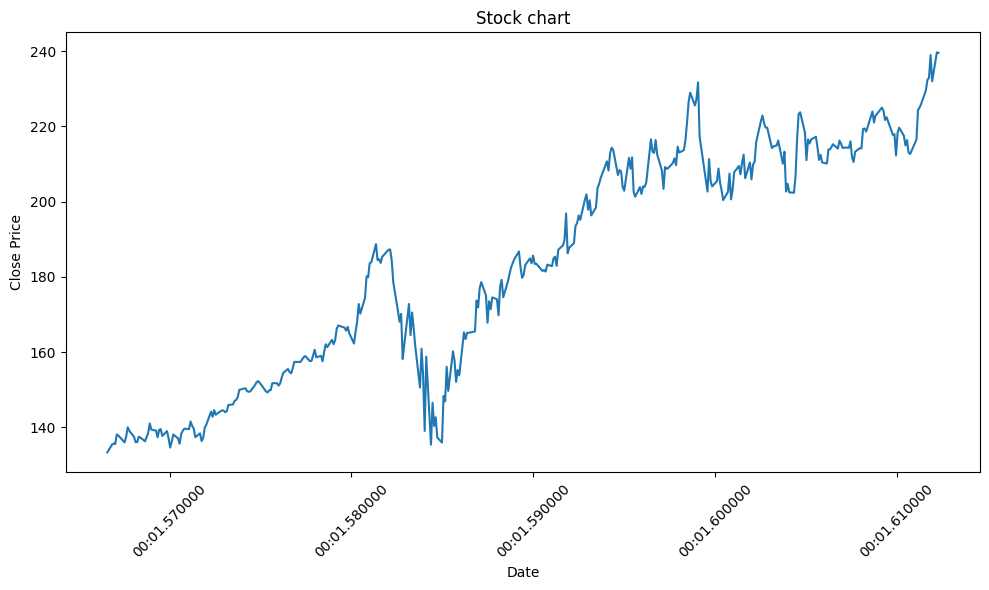

Min close: 133.39
Max close: 239.65


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
from task01 import stock
from task00 import RESULTS



stock['date'] = pd.to_datetime(stock['date'])
plt.figure(figsize=(10, 6))
plt.plot(stock['date'], stock['close'])
plt.xticks(rotation=45)
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.title('Stock chart')
plt.tight_layout()
plt.savefig('task05.png')
plt.show()
RESULTS["task05"] = {
    "min_close": float(stock['close'].min()),
    "max_close": float(stock['close'].max())
}
print(f"Min close: {stock['close'].min()}")
print(f"Max close: {stock['close'].max()}")
plt.close()

## Task 06 

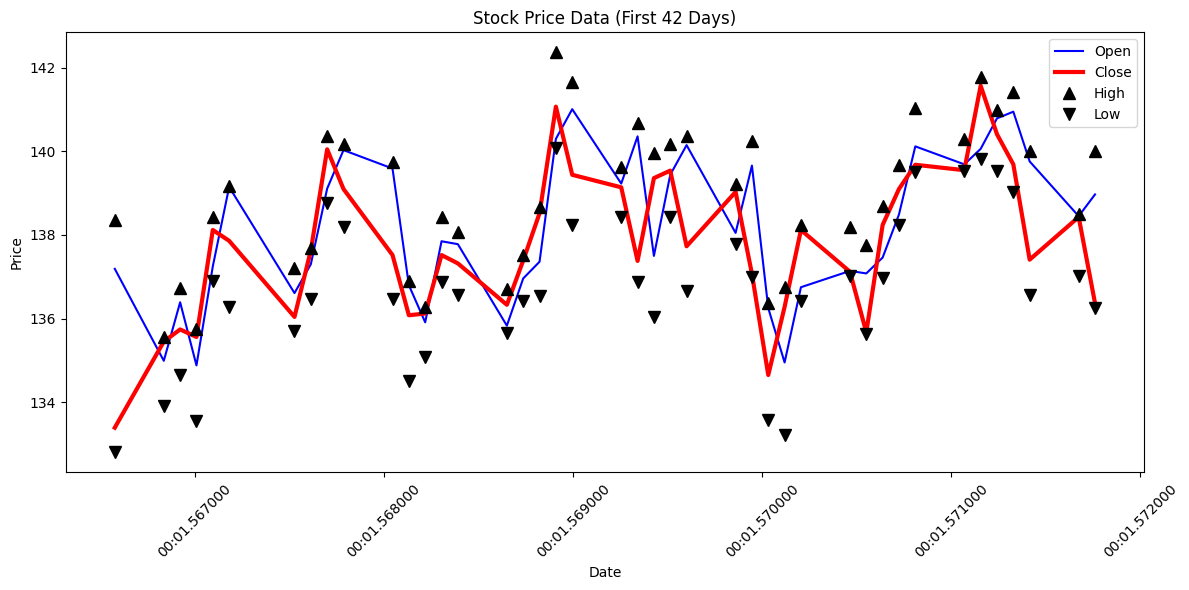

Best buy date: 1970-01-01
Best sell date: 1970-01-01
Maximum profit: 9.569999999999993


In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from task01 import stock
from task00 import RESULTS
stock_42 = stock.head(42)

plt.figure(figsize=(12, 6))
plt.plot(stock_42['date'], stock_42['open'], color='blue', label='Open')
plt.plot(stock_42['date'], stock_42['close'], color='red', linewidth=3, label='Close')
plt.plot(stock_42['date'], stock_42['high'], marker='^', color='black', 
         linewidth=0, markersize=8, label='High')
plt.plot(stock_42['date'], stock_42['low'], marker='v', color='black', 
         linewidth=0, markersize=8, label='Low')
plt.xlabel('Date')
plt.ylabel('Price')
plt.title('Stock Price Data (First 42 Days)')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig('task06.png')
plt.show()
plt.close()
max_profit = 0
best_buy_idx = 0
best_sell_idx = 0

for i in range(len(stock_42)):
    for j in range(i + 1, len(stock_42)):
        profit = stock_42.iloc[j]['high'] - stock_42.iloc[i]['low']
        if profit > max_profit:
            max_profit = profit
            best_buy_idx = i
            best_sell_idx = j

best_buy_date = stock_42.iloc[best_buy_idx]['date']
best_sell_date = stock_42.iloc[best_sell_idx]['date']
RESULTS["task06"] = {
    "best_buy_date": str(best_buy_date.date()),
    "best_sell_date": str(best_sell_date.date())
}
print(f"Best buy date: {best_buy_date.date()}")
print(f"Best sell date: {best_sell_date.date()}")
print(f"Maximum profit: {max_profit}")

## Task 07

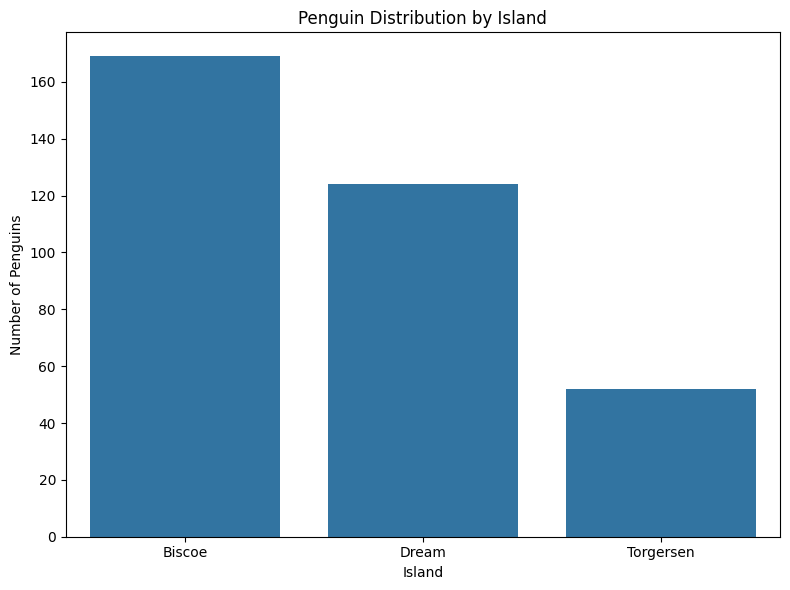

Top island: Biscoe
Count: 169


In [11]:
from task00 import RESULTS
import matplotlib.pyplot as plt
from task01 import penguins
import seaborn as sns

island_counts = penguins['island'].value_counts()
plt.figure(figsize=(8, 6))
sns.barplot(x=island_counts.index, y=island_counts.values)
plt.xlabel('Island')
plt.ylabel('Number of Penguins')
plt.title('Penguin Distribution by Island')
plt.tight_layout()
plt.savefig('task07.png')
plt.show()
plt.close()
RESULTS["task07"] = {
    "top_island": island_counts.index[0],
    "top_island_count": int(island_counts.values[0])
}

print(f"Top island: {island_counts.index[0]}")
print(f"Count: {island_counts.values[0]}")

## Task 08


Original rows: 346
After cleaning: 342


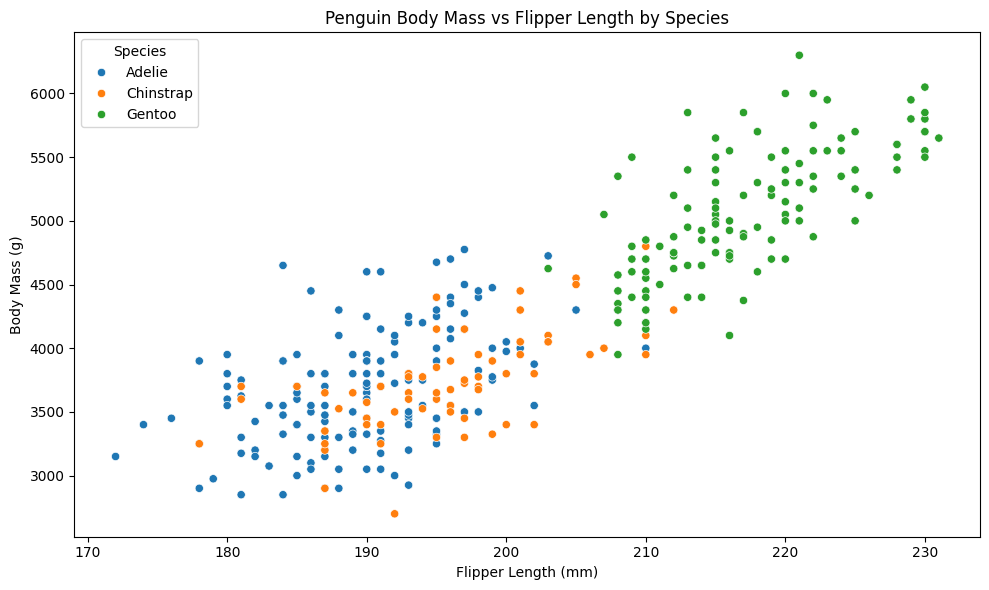

Number of unique species: 3


In [12]:
import seaborn as sns
import matplotlib.pyplot as plt
from task01 import penguins
from task00 import RESULTS
penguins_clean = penguins.dropna(subset=['flipper_length_mm', 'body_mass_g', 'species']).copy()
Q1_flipper = penguins_clean['flipper_length_mm'].quantile(0.25)
Q3_flipper = penguins_clean['flipper_length_mm'].quantile(0.75)
IQR_flipper = Q3_flipper - Q1_flipper

Q1_mass = penguins_clean['body_mass_g'].quantile(0.25)
Q3_mass = penguins_clean['body_mass_g'].quantile(0.75)
IQR_mass = Q3_mass - Q1_mass
penguins_clean = penguins_clean[
    (penguins_clean['flipper_length_mm'] >= Q1_flipper - 3 * IQR_flipper) &
    (penguins_clean['flipper_length_mm'] <= Q3_flipper + 3 * IQR_flipper) &
    (penguins_clean['body_mass_g'] >= Q1_mass - 3 * IQR_mass) &
    (penguins_clean['body_mass_g'] <= Q3_mass + 3 * IQR_mass)
]

print(f"Original rows: {len(penguins)}")
print(f"After cleaning: {len(penguins_clean)}")
plt.figure(figsize=(10, 6))
sns.scatterplot(data=penguins_clean, x='flipper_length_mm', y='body_mass_g', hue='species')
plt.xlabel('Flipper Length (mm)')
plt.ylabel('Body Mass (g)')
plt.title('Penguin Body Mass vs Flipper Length by Species')
plt.legend(title='Species')
plt.tight_layout()
plt.savefig('task08.png')
plt.show()
plt.close()
RESULTS["task08"] = {
    "species_count": int(penguins['species'].nunique())
}
print(f"Number of unique species: {penguins['species'].nunique()}")

## Task 09

Original rows: 346
After cleaning: 342
Removed 4 extreme outliers


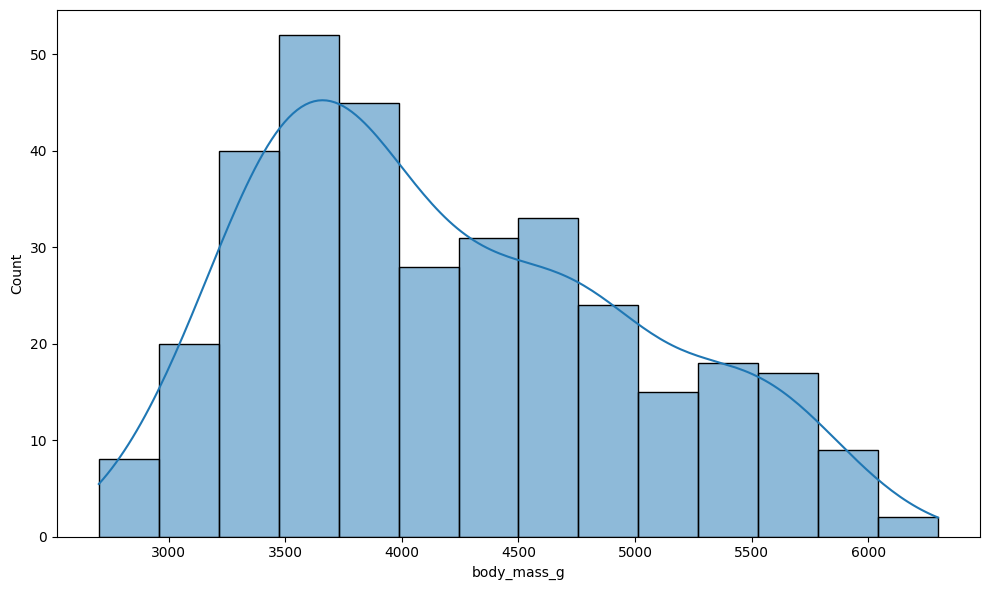

Bin width: 250
Non-null body mass values: 343


In [13]:
import seaborn as sns
import matplotlib.pyplot as plt
from task01 import penguins
from task00 import RESULTS
penguins_clean = penguins[
    (penguins['body_mass_g'] >= 2000) & 
    (penguins['body_mass_g'] <= 7000)
].copy()

print(f"Original rows: {len(penguins)}")
print(f"After cleaning: {len(penguins_clean)}")
print(f"Removed {len(penguins) - len(penguins_clean)} extreme outliers")

bin_width = 250
min_mass = penguins_clean['body_mass_g'].min() 
max_mass = penguins_clean['body_mass_g'].max()
num_bins = int((max_mass - min_mass) / bin_width)

plt.figure(figsize=(10, 6))
sns.histplot(data=penguins_clean, x='body_mass_g', bins=num_bins, kde=True) 
plt.xlabel('body_mass_g')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('task09.png')
plt.show()
plt.close()

RESULTS["task09"] = {
    "bins_width": 250,
    "non_null_body_mass": int(penguins['body_mass_g'].notna().sum())
}

print(f"Bin width: 250")
print(f"Non-null body mass values: {penguins['body_mass_g'].notna().sum()}")

## Task 10

Original rows: 346
Rows after removing NaN: 343

Correlation Matrix:
                   flipper_length_mm  culmen_length_mm  culmen_depth_mm  \
flipper_length_mm           1.000000          0.999881         0.999496   
culmen_length_mm            0.999881          1.000000         0.999419   
culmen_depth_mm             0.999496          0.999419         1.000000   
body_mass_g                 0.999950          0.999821         0.999704   

                   body_mass_g  
flipper_length_mm     0.999950  
culmen_length_mm      0.999821  
culmen_depth_mm       0.999704  
body_mass_g           1.000000  


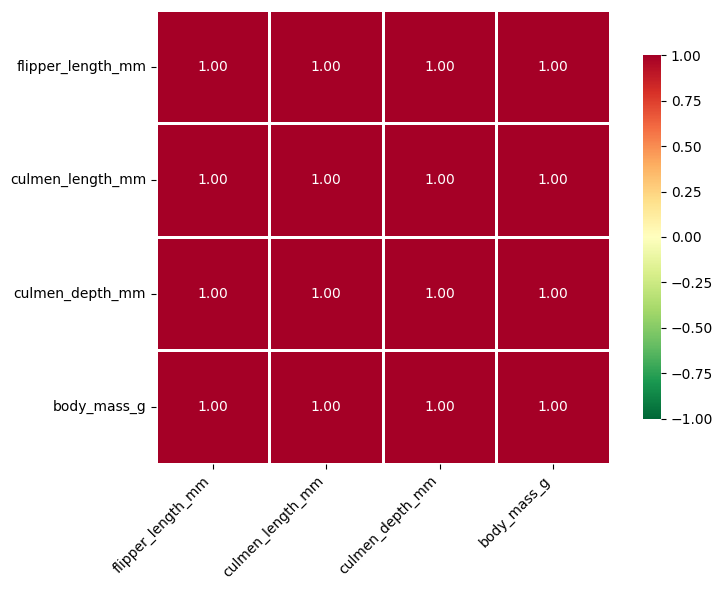


Most correlated pair: ['body_mass_g', 'flipper_length_mm']
Correlation value: 0.9999


In [14]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from task01 import penguins
from task00 import RESULTS

cols = ['flipper_length_mm', 'culmen_length_mm', 'culmen_depth_mm', 'body_mass_g']
penguins_subset = penguins[cols].dropna()

print(f"Original rows: {len(penguins)}")
print(f"Rows after removing NaN: {len(penguins_subset)}")
corr_matrix = penguins_subset.corr()
print("\nCorrelation Matrix:")
print(corr_matrix)

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn_r', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8}, 
            fmt='.2f', vmin=-1, vmax=1)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('task10.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()
corr_matrix_no_diag = corr_matrix.values.copy()
np.fill_diagonal(corr_matrix_no_diag, np.nan)

max_corr = 0
top_pair = []

for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        corr_value = abs(corr_matrix_no_diag[i, j])
        if pd.notna(corr_value) and corr_value > max_corr:
            max_corr = corr_value
            col1 = corr_matrix.columns[i]
            col2 = corr_matrix.columns[j]
            top_pair = sorted([col1, col2])
RESULTS["task10"] = {
    "top_pair": top_pair
}
print(f"\nMost correlated pair: {top_pair}")
print(f"Correlation value: {max_corr:.4f}")

## Task 11

In [17]:
import folium
from folium.plugins import MarkerCluster
from task01 import michelin
from task00 import RESULTS

michelin_clean = michelin.dropna(subset=['latitude', 'longitude']).copy()

michelin_clean = michelin_clean[
    (michelin_clean['latitude'] >= -90) & 
    (michelin_clean['latitude'] <= 90) &
    (michelin_clean['longitude'] >= -180) & 
    (michelin_clean['longitude'] <= 180)
]

print(f"Total restaurants: {len(michelin)}")
print(f"Restaurants with valid coordinates: {len(michelin_clean)}")

world_map = folium.Map(location=[20, 0], zoom_start=2)
marker_cluster = MarkerCluster().add_to(world_map)
markers_added = 0
for idx, row in michelin_clean.iterrows():
    popup_text = f"{row.get('name', 'Unknown')} - {row.get('city', 'Unknown city')}"

    folium.Marker(
        location=[row['latitude'], row['longitude']],
        popup=popup_text,
        icon=folium.Icon(color='red', icon='cutlery', prefix='fa')
    ).add_to(marker_cluster)
    
    markers_added += 1
world_map.save('task11.html')
 
RESULTS["task11"] = {
    "markers": markers_added
}

print(f"Markers added: {markers_added}")
print("Map saved as task11.html")

Total restaurants: 1244
Restaurants with valid coordinates: 1244
Markers added: 1244
Map saved as task11.html


## Task 12

In [19]:
import pandas as pd
import folium
from task01 import michelin
from task00 import RESULTS
manhattan_restaurants = michelin[
    (michelin['latitude'] >= 40.7) & 
    (michelin['latitude'] <= 40.88) &
    (michelin['longitude'] >= -74.02) & 
    (michelin['longitude'] <= -73.91)
].copy()

print(f"Restaurants in Manhattan bounds: {len(manhattan_restaurants)}")
manhattan_map = folium.Map(
    location=[40.7831, -73.9712], 
    zoom_start=13,
    tiles='OpenStreetMap'
)
star_colors = {
    1: 'green',
    2: 'orange',
    3: 'red'
}
nb_markers_1 = 0
nb_markers_2 = 0
nb_markers_3 = 0
for idx, row in manhattan_restaurants.iterrows():
    if pd.notna(row.get('latitude')) and pd.notna(row.get('longitude')):
        stars = row.get('stars', 0)
        if stars == 1:
            color = 'green'
            nb_markers_1 += 1
        elif stars == 2:
            color = 'orange'
            nb_markers_2 += 1
        elif stars == 3:
            color = 'red'
            nb_markers_3 += 1
        else:
            continue

        popup_text = f"{row.get('name', 'Unknown')} - {stars} star(s)"

        folium.Marker(
            location=[row['latitude'], row['longitude']],
            popup=popup_text,
            icon=folium.Icon(color=color, icon='star')
        ).add_to(manhattan_map)

manhattan_map.save('task12.html')
RESULTS["task12"] = {
    "nb_markers_1": nb_markers_1,
    "nb_markers_2": nb_markers_2,
    "nb_markers_3": nb_markers_3
}

print(f"1-star restaurants: {nb_markers_1}")
print(f"2-star restaurants: {nb_markers_2}")
print(f"3-star restaurants: {nb_markers_3}")
print("Map saved as task12.html")

Restaurants in Manhattan bounds: 124
1-star restaurants: 53
2-star restaurants: 67
3-star restaurants: 4
Map saved as task12.html


## Task 13

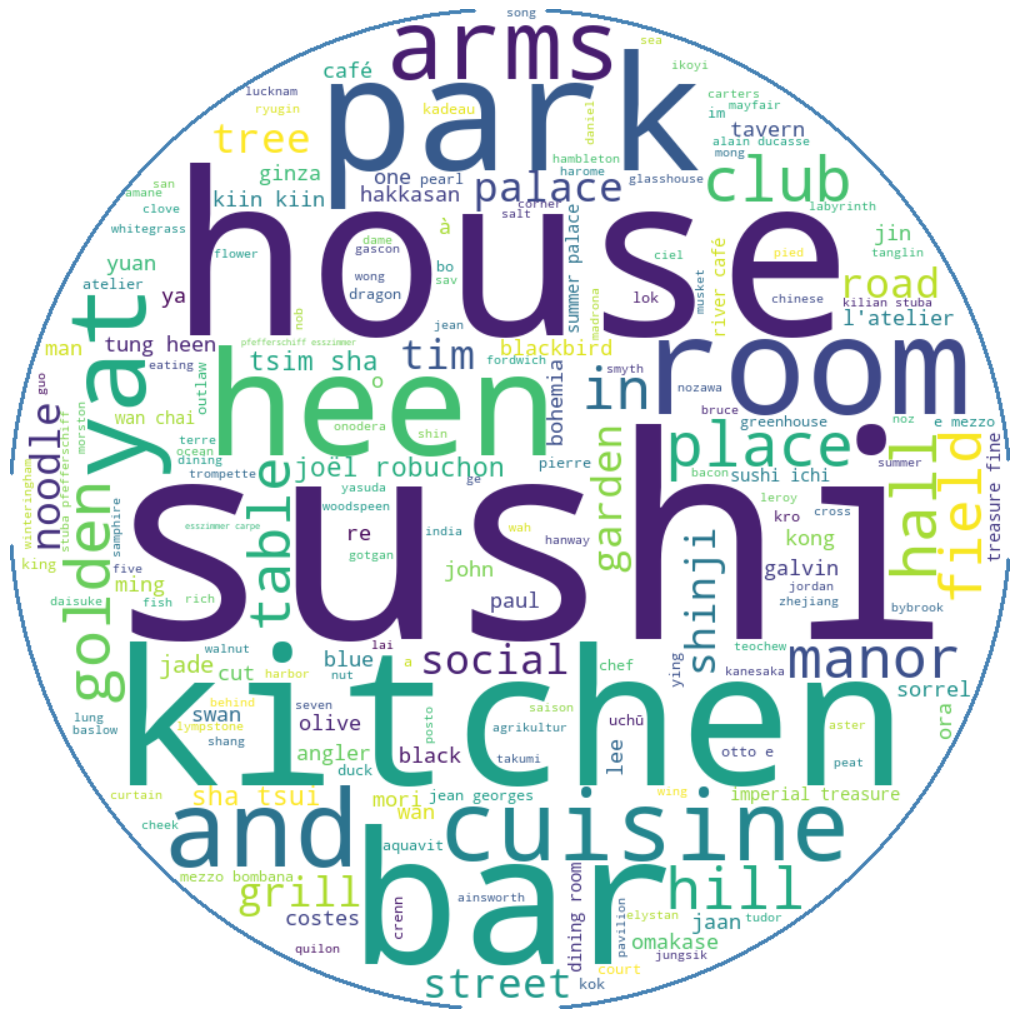

In [20]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import numpy as np
from task01 import michelin
from task00 import RESULTS
from collections import Counter

# Get all restaurant names and convert to lowercase
names = michelin['name'].dropna().str.lower()
text = ' '.join(names)

# Define stopwords
stopwords = {
    'the', 'le', 'los', 'ho', 'da', 'of', 'at', 'fu', 'inn', 'lei',
    'la', 'el', 'del', 'di', 'de', 'des', 'du', 'et', 'al', 'il',
    'lo', 'las', 'les', 'l', 'chez', 'casa', 'per', 'au', 'by', 'restaurant'
}

# Create circular mask
x, y = np.ogrid[:800, :800]
mask = (x - 400) ** 2 + (y - 400) ** 2 > 400 ** 2
mask = 255 * mask.astype(int)

# Create word cloud with circular mask
wordcloud = WordCloud(
    width=800,
    height=800,
    background_color='white',
    stopwords=stopwords,
    random_state=42,
    mask=mask,
    contour_width=2,
    contour_color='steelblue'
).generate(text)

# Display and save
plt.figure(figsize=(10, 10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.tight_layout(pad=0)
plt.savefig('task13.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()

# Find most frequent word
words = text.split()
words_filtered = [word for word in words if word not in stopwords]
word_counts = Counter(words_filtered)
top_word = words

## Task 14

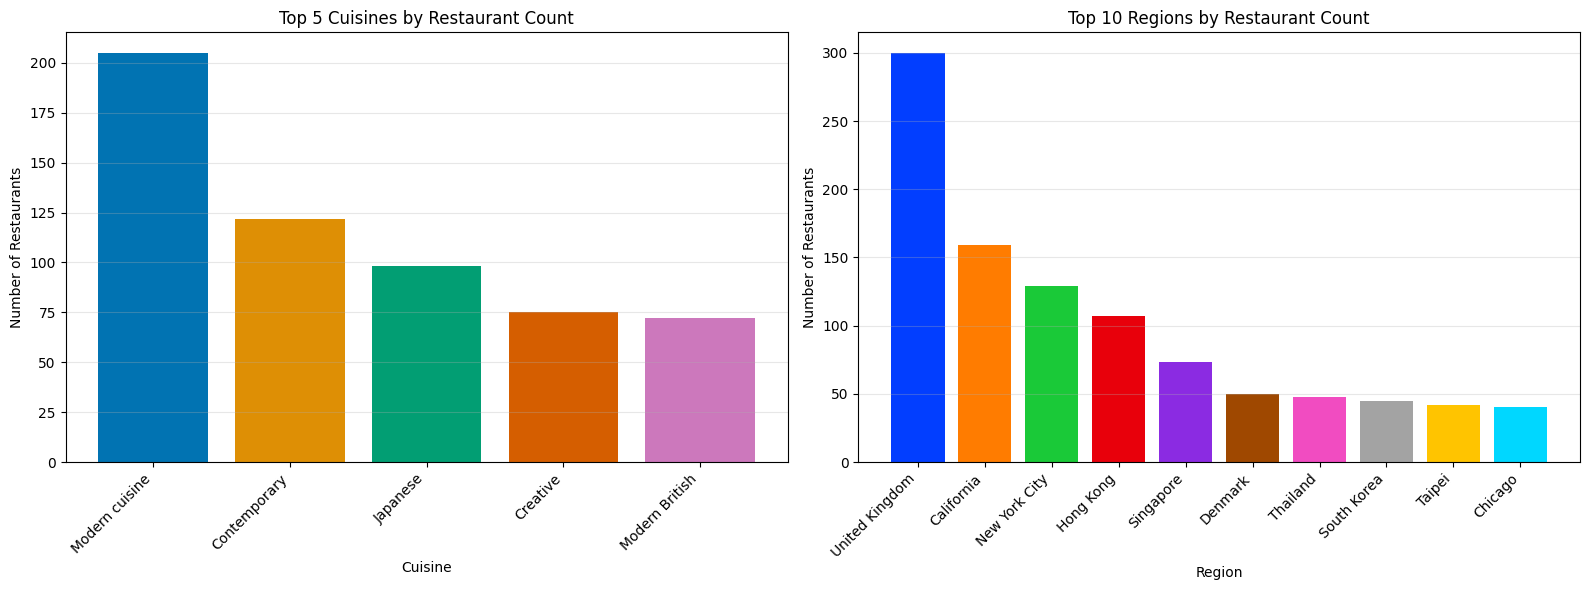

Top 5 cuisines: ['Modern cuisine', 'Contemporary', 'Japanese', 'Creative', 'Modern British']
Top 10 regions: ['United Kingdom', 'California', 'New York City', 'Hong Kong', 'Singapore', 'Denmark', 'Thailand', 'South Korea', 'Taipei', 'Chicago']


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from task01 import michelin
from task00 import RESULTS

top5_cuisine = michelin['cuisine'].value_counts().head(5)
top5_cuisine_names = top5_cuisine.index.tolist()
top10_region = michelin['region'].value_counts().head(10)
top10_region_names = top10_region.index.tolist()
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
colorblind_palette = sns.color_palette("colorblind", n_colors=5)
ax1.bar(range(len(top5_cuisine)), top5_cuisine.values, color=colorblind_palette)
ax1.set_xticks(range(len(top5_cuisine)))
ax1.set_xticklabels(top5_cuisine_names, rotation=45, ha='right')
ax1.set_xlabel('Cuisine')
ax1.set_ylabel('Number of Restaurants')
ax1.set_title('Top 5 Cuisines by Restaurant Count')
ax1.grid(axis='y', alpha=0.3)
bright_palette = sns.color_palette("bright", n_colors=10)
ax2.bar(range(len(top10_region)), top10_region.values, color=bright_palette)
ax2.set_xticks(range(len(top10_region)))
ax2.set_xticklabels(top10_region_names, rotation=45, ha='right')
ax2.set_xlabel('Region')
ax2.set_ylabel('Number of Restaurants')
ax2.set_title('Top 10 Regions by Restaurant Count')
ax2.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('task14.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()

RESULTS["task14"] = {
    "top5_cuisine": top5_cuisine_names,
    "top10_region": top10_region_names
}

print(f"Top 5 cuisines: {top5_cuisine_names}")
print(f"Top 10 regions: {top10_region_names}")

## Task 15

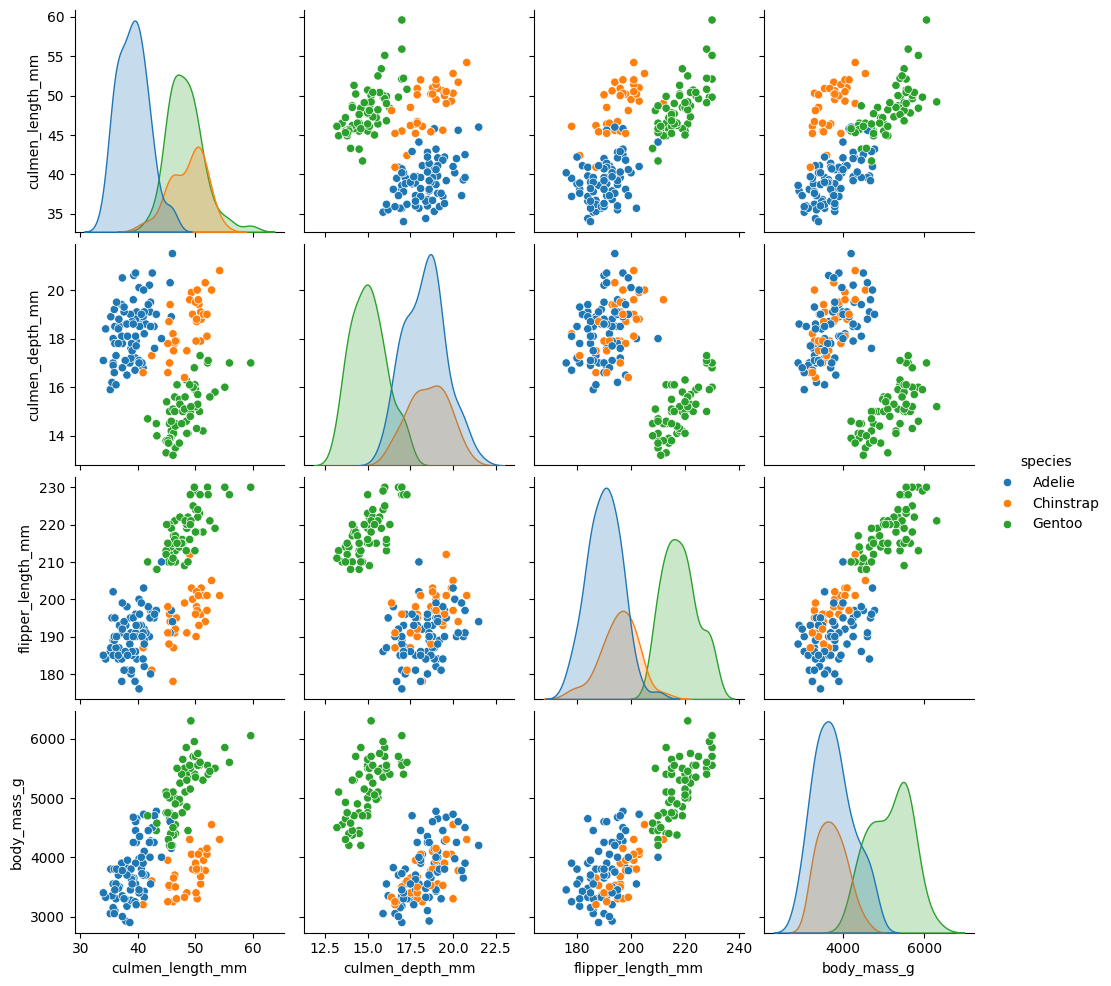

Number of numeric columns: 4


In [22]:
import seaborn as sns
import matplotlib.pyplot as plt
from task01 import penguins
from task00 import RESULTS
numeric_cols = penguins.select_dtypes(include=['float64', 'int64']).columns.tolist()
penguins_sample = penguins.sample(frac=0.5, random_state=42)
sns.pairplot(penguins_sample, hue='species', diag_kind='kde')
plt.savefig('task15.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()
RESULTS["task15"] = {
    "numeric_cols": len(numeric_cols),
    "sampled": True,
    "sample_fraction": 0.5
}

print(f"Number of numeric columns: {len(numeric_cols)}")